# ML for linear regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data preparation

In [ ]:
df=pd.read_csv("data/data.csv")
df.columns=df.columns.str.lower().str.replace(" ","_")
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
strings=list(df.dtypes[df.dtypes=="object"].index) #solo queremos objetos
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [ ]:
for col in strings:
    df[col]=df[col].str.lower().str.replace(" ","_") #reemplazamos espacios por guiones bajos y pasamos a minusculas

In [ ]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


## EDA

In [ ]:
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [ ]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

### Distribución de variables

In [ ]:
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

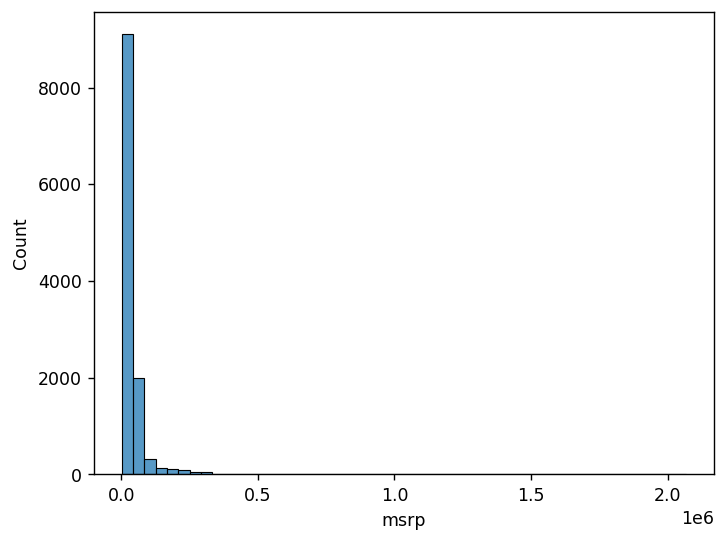

In [ ]:
sns.histplot(df.msrp,bins=50)

##### Muchos autos son baratos, por ende destaca una sola barra, pero a su vez hay "outliers" que hacen que el gráfico se extienda bastante por la cola derecha. Podemos aplicar distribución logarítmica (recordemos que no podemos tener 0)

<Axes: xlabel='msrp', ylabel='Count'>

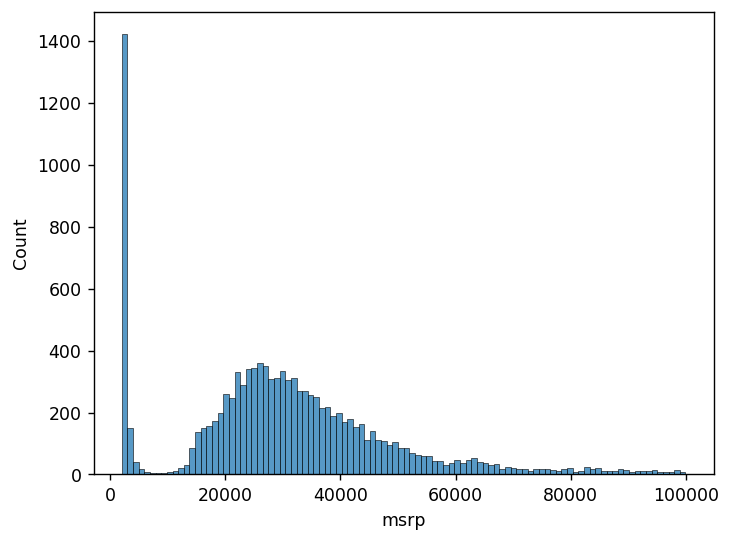

In [ ]:
sns.histplot(df.msrp[df.msrp<100000],bins=100)

In [ ]:
price_logs=np.log1p(df.msrp)
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

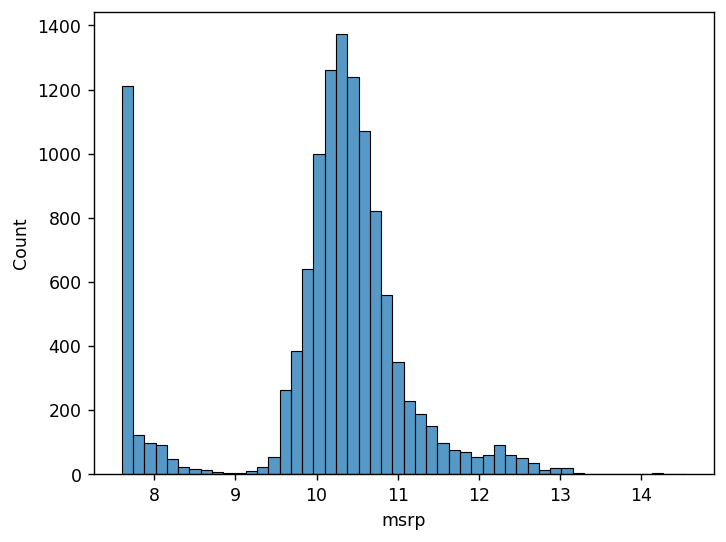

In [ ]:
sns.histplot(price_logs,bins=50)

### Valores faltantes

In [ ]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## Entorno de validación
#### El dataset se divide entres partes: entrenamiento (60%), validación (20%) y test (20%). Para cada parte, creamos una matriz Xy.

In [ ]:
n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train=n-n_val-n_test
n,n_val+n_test+n_train 

(11914, 11914)

In [ ]:
n_val,n_test,n_train

(2382, 2382, 7150)

In [ ]:
df_train=df.iloc[n_train:]
df_val=df.iloc[n_train:n_train+n_val]
df_test=df.iloc[n_train+n_val:] 
#esto no  nos va a servir porque el dataframe tenía un orden predeterminado, por ejemplo, todas los autos bmw estaban juntos

In [ ]:
idx=np.arange(n)

In [ ]:
np.random.seed(2)
np.random.shuffle(idx)
idx #indices aleatorios

array([2735, 6720, 5878, ..., 6637, 2575, 7336])

In [ ]:
df_train=df.iloc[idx[:n_train]]
df_val=df.iloc[idx[n_train:n_train+n_val]]
df_test=df.iloc[idx[n_train+n_val:]] # uso idx para que los conjuntos de train, validation y test sean aleatorios

In [ ]:
len(df_train),len(df_test),len(df_val)

(7150, 2382, 2382)

In [ ]:
df_train=df_train.reset_index(drop=True)
df_val=df_test.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

In [ ]:
y_train=np.log1p(df_train.msrp.values) # el .values sirve para haerlo como una matriz
y_val=np.log1p(df_val.msrp.values)
y_test=np.log1p(df_test.msrp.values)


In [ ]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

## Regresión lineal

$g(x_{i})\approx y_{i}$


$x_{i}=(x_{i1},x_{i2},...,x_{in})$ $\rightarrow$ son las diferentes especificaciones de los autos

$g(x_{i1},...,x_{in}) \approx y_{i}$ $\rightarrow$ esto es lo que queremos estimar



In [ ]:
df_train.iloc[10] #primero entrenamos (es decir, usamos el train)

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

### Implementación

$g(x_{i})=w_{0}+w_{1}x_{i1}+w_{2}x_{i2}+... \rightarrow$ formula de la regresión lineal

$g(x_{i})=w_{0}+\Sigma_{j=0}^{n-1}w_{j}x_{ij} \rightarrow$ formula generalizada (para el caso de Python donde el conteo empieza en 0 y no en 1)

In [ ]:
xi=[453,11,86]
w0=5.234
wi=[0.4,0.01,0.005]

In [ ]:
def linear_regression(xi):
    n=len(xi)
    pred=w0
    for j in range(n):
        pred=pred+wi[j]*xi[j]
    return pred



In [ ]:
linear_regression(xi)

186.97400000000005

In [ ]:
np.log1p(186.97400000000005)

np.float64(5.236303655393576)

## Regresión lineal: forma vectorial

Recordando, 

$$g(x_{i})=w_{0}+\Sigma_{j=0}^{n-1}w_{j}x_{ij}$$ 

El segundo término no es más que un producto punto, por lo que se puede expresar 

$$g(x_{i})=w_{0}+X_{i}^Tw$$


In [ ]:
def dot_product(xi,wi):
    n=len(xi)
    res=0.0
    for j in range(n):
        res=res+xi[j]*wi[j]
    return res

In [ ]:
w_new=[w0]+wi
w_new

[5.234, 0.4, 0.01, 0.005]

In [ ]:
def linear_regression(xi):
    xi=[1]+xi
    return dot_product(xi,w_new)

In [ ]:
linear_regression(xi)

186.97400000000005

In [ ]:
x1=[1,148,24,1385]
x2=[1,136,26,1244]
x3=[1,453,11,86]

x=[x1,x2,x3]
X=np.array(x)
X

array([[   1,  148,   24, 1385],
       [   1,  136,   26, 1244],
       [   1,  453,   11,   86]])

In [ ]:
X.dot(w_new)

array([ 71.599,  66.114, 186.974])

## Entrenamiento de una regresión lineal: ecuación normal

Lo que buscamos es que $g(x)=Xw=Y$, pero es muy dificil que sea $Xw=Y$, por lo que tratamos de resolver ese sistema tratando de encontrar el $w$.

Suponemos que $X$ es invertible por lo que, multiplicando ambos miembros por $X^{-1}$,

$$X^{-1}Xw=X^{-1}Y$$

$$Iw=X^{-1}Y$$

Ahora bien, $X$ debe ser invertible, caso contrario no se podría solucionar este sistema.

Otra solución es como sigue: multiplicamos ambos miembros por la transpuesta de X

$$X^{T}Xw=X^{T}Y$$

y como $X^{T}X$ es una matriz cuadrada, su inversa existe, por lo que, multiplicando ambos lados,

$$(X^{T}X)^{-1}X^{T}Xw=(X^{T}X)^{-1}X^{T}Y$$

$$\boxed{w=(X^{T}X)^{-1}X^{T}Y}$$

donde $w$ es la solución posible más cercana a la ideal


In [ ]:
def train_linear_regression(X,y):
    pass

In [ ]:
x=[
[148,24,453],
[136,26,564],
[453,11,264],
[178,44,605],
[126,23,233],
[483,44,756],
[118,34,234],
[126,12,143],
[453,71,432],
]
X=np.array(x)
X

array([[148,  24, 453],
       [136,  26, 564],
       [453,  11, 264],
       [178,  44, 605],
       [126,  23, 233],
       [483,  44, 756],
       [118,  34, 234],
       [126,  12, 143],
       [453,  71, 432]])

In [ ]:
y=[100,354,786,123,234,768,452,926,275]

In [ ]:
XTX=X.T.dot(X)
XTX

array([[ 761467,   81740, 1006862],
       [  81740,   12115,  134027],
       [1006862,  134027, 1846680]])

In [ ]:
XTX_inv=np.linalg.inv(XTX)

In [ ]:
w_full=XTX_inv.dot(X.T).dot(y)

In [ ]:
w0=w_full[0]
w=w_full[1:]

In [ ]:
w0,w

(np.float64(1.6876104064487578), array([-5.87425098,  0.32875671]))

In [ ]:
def train_linear_regression(X,y):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])
    XTX=X.T.dot(X)
    XTX_inv=np.linalg.inv(XTX)
    w_full=XTX_inv.dot(X.T).dot(y)
    return w_full[0],w_full[1:]

In [ ]:
train_linear_regression(X,y)

(np.float64(557.8603593305188), array([ 1.27503107, -9.42959078, -0.3011497 ]))

## Modelo básico para estimar el precio de los autos

In [ ]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='object')

In [ ]:
base=['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']

In [ ]:
X_train=df_train[base].values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]])

In [ ]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [ ]:
X_train=df_train[base].fillna(0).values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]])

In [ ]:
w0,w=train_linear_regression(X_train,y_train)

In [ ]:
y_pred=w0+X_train.dot(w)
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111])

<Axes: ylabel='Count'>

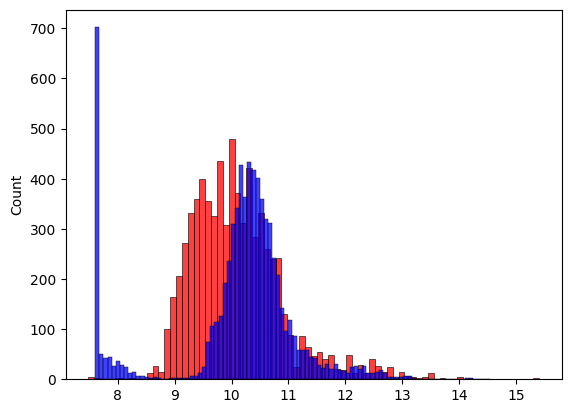

In [ ]:
sns.histplot(y_pred,color='red') #predicciones
sns.histplot(y_train,color='blue') #target

##  RMSE

$$RMSE=\sqrt{\frac{1}n}\Sigma_{i=1}^{n}(g(x_{i})-y_{i})^2}$$

donde $(g(x_{i})-y_{i})^2$ son las diferencias al cuadrado de las predicciones ($g(x_{i})$) y los valores efectivos ($y_{i}$). $n$ es la cantidad de observaciones.

In [ ]:
def rmse(y,y_pred):
    error=y-y_pred
    se=error**2
    mse=se.mean()
    return np.sqrt(mse)

In [ ]:
rmse(y_train,y_pred)

np.float64(0.7554192603920132)

## Validando el modelo

In [ ]:
base=['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']

X_train=df_train[base].fillna(0).values

w0,w=train_linear_regression(X_train,y_train)

y_pred=w0+X_train.dot(w)


In [ ]:
def prepare_X(df):
    df_num=df[base] # selecciono las columnas que me interesan
    df_num=df_num.fillna(0) # relleno los valores nulos con 0
    X=df_num.values # convierto a un array de NumPy
    return X

In [ ]:
X_train=prepare_X(df_train)
w0,w=train_linear_regression(X_train,y_train)
X_val=prepare_X(df_val)
y_pred=w0+X_val.dot(w)
rmse(y_val,y_pred)

np.float64(0.7359130757318697)

## Ingeniería de atributos simple

In [ ]:
2017-df_train.year #queremos ver la edad de los autos, por lo que vamos a crear una nueva columna, que será 2017 menos el año del auto.

0        9
1        5
2        1
3       26
4        0
        ..
7145     2
7146     2
7147     2
7148     3
7149     0
Name: year, Length: 7150, dtype: int64

In [ ]:
def prepare_X(df):
    df=df.copy() # hacemos una copia del dataframe para no modificar el original
    df['age']=2017-df.year # creamos la nueva columna 'age'
    features=base+['age'] # agregamos la nueva columna a la lista de columnas que nos interesan

    df_num=df[features] # seleccionamos las columnas que nos interesan
    df_num=df_num.fillna(0) # relleno los valores nulos con 0
    X=df_num.values # convierto a un array de NumPy
    return X

In [ ]:
X_train=prepare_X(df_train)
w0,w=train_linear_regression(X_train,y_train)
X_val=prepare_X(df_val)
y_pred=w0+X_val.dot(w)
rmse(y_val,y_pred)

np.float64(0.5149229218585313)

<Axes: ylabel='Count'>

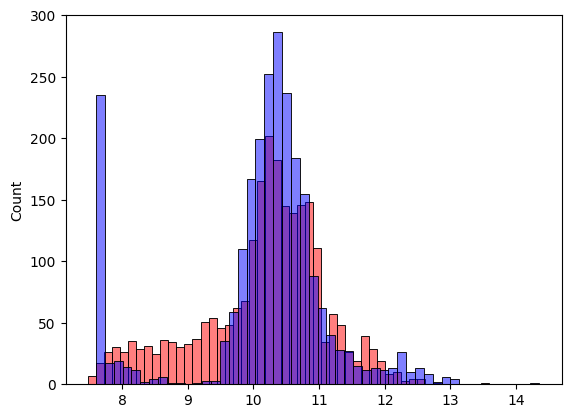

In [ ]:
sns.histplot(y_pred,color='red',alpha=0.5,bins=50) #predicciones
sns.histplot(y_val,color='blue',alpha=0.5,bins=50) #target

## Variable categóricas

Son las variables que son, justamente, categorías (strings).

Las variables categóricas se representan con una columna por cada categoría, la cual va a ser del tipo binaria (booleana).

In [ ]:
for v in [2,3,4]: #esta variable no es numerica, si no es el tipo de auto, es decir, tres puertas, cinco puertas, dos puertas, etc.
     df_train['number_doors_%s' % v]=(df_train.number_of_doors==v).astype(int) #creamos una nueva columna que será 1 si el auto tiene ese número de puertas y 0 si no lo tiene

In [ ]:
def prepare_X(df):
    df=df.copy() # hacemos una copia del dataframe para no modificar el original
    features=base.copy() # hacemos una copia de la lista de columnas que nos interesan
    
    df['age']=2017-df.year # creamos la nueva columna 'age'
    features.append('age') # agregamos la nueva columna a la lista de columnas que nos interesan

    for v in [2,3,4]: 
     df['number_doors_%s' % v]=(df.number_of_doors==v).astype(int)
     features.append('number_doors_%s' % v) # agregamos las nuevas columnas a la lista de columnas que nos interesan

    df_num=df[features] # seleccionamos las columnas que nos interesan
    df_num=df_num.fillna(0) # relleno los valores nulos con 0
    X=df_num.values # convierto a un array de NumPy
    return X

In [ ]:
X_train=prepare_X(df_train)
w0,w=train_linear_regression(X_train,y_train)
X_val=prepare_X(df_val)
y_pred=w0+X_val.dot(w)
rmse(y_val,y_pred)

np.float64(0.5133819172833147)

In [ ]:
makes=list(df.make.value_counts().head().index) # muestra los valores más frecuentes de la columna 'make'

In [ ]:
def prepare_X(df):
    df=df.copy() # hacemos una copia del dataframe para no modificar el original
    features=base.copy() # hacemos una copia de la lista de columnas que nos interesan
    
    df['age']=2017-df.year # creamos la nueva columna 'age'
    features.append('age') # agregamos la nueva columna a la lista de columnas que nos interesan

    for v in [2,3,4]: 
        df['number_doors_%s' % v]=(df.number_of_doors==v).astype(int)
        features.append('number_doors_%s' % v) # agregamos las nuevas columnas a la lista de columnas que nos interesan

    for v in makes: 
        df['make_%s' % v]=(df.make==v).astype(int)
        features.append('make_%s' % v) # agregamos las nuevas columnas a la lista de columnas que nos interesan

    df_num=df[features] # seleccionamos las columnas que nos interesan
    df_num=df_num.fillna(0) # relleno los valores nulos con 0
    X=df_num.values # convierto a un array de NumPy
    return X

In [ ]:
X_train=prepare_X(df_train)
w0,w=train_linear_regression(X_train,y_train)
X_val=prepare_X(df_val)
y_pred=w0+X_val.dot(w)
rmse(y_val,y_pred)

np.float64(0.5050722255722621)

In [ ]:
#diccionario de categorias
variables_categoricas=['make','engine_fuel_type','transmission_type','driven_wheels','market_category','vehicle_size','vehicle_style']

In [ ]:
categorias={}
for c in variables_categoricas:
    categorias[c]=list(df[c].value_counts().head().index) # muestra los valores más frecuentes de cada columna

categorias


{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [ ]:
def prepare_X(df):
    df=df.copy() # hacemos una copia del dataframe para no modificar el original
    features=base.copy() # hacemos una copia de la lista de columnas que nos interesan
    
    df['age']=2017-df.year # creamos la nueva columna 'age'
    features.append('age') # agregamos la nueva columna a la lista de columnas que nos interesan

    for v in [2,3,4]: 
        df['number_doors_%s' % v]=(df.number_of_doors==v).astype(int)
        features.append('number_doors_%s' % v) # agregamos las nuevas columnas a la lista de columnas que nos interesan

    for c,values in categorias.items(): # iteramos sobre el diccionario de categorias
        for v in values: # iteramos sobre los valores de cada categoria
            df['%s_%s' % (c,v)]=(df[c]==v).astype(int) # creamos una nueva columna que será 1 si el auto tiene esa categoria y 0 si no la tiene
            features.append('%s_%s' % (c,v)) # agregamos las nuevas columnas a la lista de columnas que nos interesan

    df_num=df[features] # seleccionamos las columnas que nos interesan
    df_num=df_num.fillna(0) # relleno los valores nulos con 0
    X=df_num.values # convierto a un array de NumPy
    return X

In [ ]:
X_train=prepare_X(df_train)
w0,w=train_linear_regression(X_train,y_train)
X_val=prepare_X(df_val)
y_pred=w0+X_val.dot(w)
rmse(y_val,y_pred)

np.float64(22.13284989375823)

## Regularización

Buscamos seleccionar las mejores variables para así poder tener un mejor modelo (tratando de bajar el RMSE).

Si recordamos,

 $$w=(X^{T}X)^{-1}X^{T}y$$ 

 El problema surge cuando hay _features_ muy parecidas que generan que el termino $(X^{T}X)^{-1}$ no exista (dado que no existe la inversa de esa matriz). Se hará un ejemplo

In [ ]:
X=[
    [4,4,4],
    [3,5,5],
    [5,1,1],
    [5,4,4],
    [7,5,5],
    [4,5,5]
]
X=np.array(X)

In [ ]:
XTX=X.T.dot(X) #en este caso, una columna es una combinación lineal de otra

In [ ]:
np.linalg.inv(XTX) #la matriz es singular (su determinante es igual a 0)

LinAlgError: Singular matrix

In [ ]:
#supongamos que uno de los elementos el ligeramente distinto
X=[
    [4,4,4],
    [3,5,5],
    [5,1,1],
    [5,4,4],
    [7,5,5],
    [4,5,5.0000001]
]
X=np.array(X)

y=[1,2,3,1,2,3]

In [ ]:
XTX=X.T.dot(X)

In [ ]:
XTX_inv=np.linalg.inv(XTX)

In [ ]:
XTX_inv #existe

array([[ 3.92646538e-02, -1.54615164e+05,  1.54615121e+05],
       [-1.54615170e+05,  3.51843724e+13, -3.51843721e+13],
       [ 1.54615129e+05, -3.51843721e+13,  3.51843718e+13]])

In [ ]:
XTX_inv.dot(X.T).dot(y) #en este caso los valores de los pesos (excepcuando el primero) son demasiado altos

array([ 2.73776578e-01, -4.41093100e+06,  4.41093113e+06])

### Solucion del problema

Para resolver el problema, la primera solución es sumar valores pequeños a la diagonal principal de la matriz

In [ ]:
XTX=[
    [4,4,4],
    [3,5,5],
    [5,1,1]
]
XTX=np.array(XTX)
np.linalg.inv(XTX)

LinAlgError: Singular matrix

In [ ]:
XTX=[
    [4,4,4],
    [3,5,5],
    [5,1,1.00000001]
]
XTX=np.array(XTX)
np.linalg.inv(XTX)

array([[ 6.24999928e-01, -4.99999940e-01,  2.98023224e-08],
       [ 2.74999965e+08, -1.99999974e+08, -9.99999873e+07],
       [-2.74999965e+08,  1.99999975e+08,  9.99999873e+07]])

In [ ]:
XTX=[
    [4.01,4,4],
    [3,5.01,5],
    [5,1,1.01]
]
XTX=np.array(XTX)
np.linalg.inv(XTX)

array([[  -0.76076912,    0.50633552,    0.50633552],
       [-278.10478614,  201.90002405,  101.90002405],
       [ 279.11745718, -202.40762541, -102.40762541]])

1000001.88

In [ ]:
XTX=[
    [4,4,4],
    [3,5,5.00000001],
    [5,1,1]
]
XTX=np.array(XTX)

XTX=XTX+0.01*np.eye(3) # np.eye(3) crea una matriz identidad de 3x3, que se suma a XTX


In [ ]:
np.linalg.inv(XTX)

array([[  -0.76077054,    0.50633655,    0.50633604],
       [-278.10534968,  201.90043271,  101.90023081],
       [ 279.11802214, -202.4080351 , -102.40783269]])

In [ ]:
def train_linear_regression_reg(X,y,r=0.01):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])

    XTX=X.T.dot(X)
    XTX=XTX+r*np.eye(XTX.shape[0]) # shape[0] devuelve el número de filas de la matriz XTX, que es el mismo que el número de columnas, ya que XTX es una matriz cuadrada. Por lo tanto, np.eye(XTX.shape[0]) crea una matriz identidad del mismo tamaño que XTX, y al multiplicarla por 0.01 se obtiene una matriz diagonal con 0.01 en la diagonal principal y 0 en el resto de los elementos. Al sumar esta matriz a XTX, se obtiene una nueva matriz que es más estable numéricamente y que permite calcular su inversa sin problemas.
    
    XTX_inv=np.linalg.inv(XTX)
    w_full=XTX_inv.dot(X.T).dot(y)

    return w_full[0],w_full[1:]

In [ ]:
X_train=prepare_X(df_train)
w0,w=train_linear_regression_reg(X_train,y_train,r=0.01) #¿cuál es el mejor 'r'?
X_val=prepare_X(df_val)
y_pred=w0+X_val.dot(w)
rmse(y_val,y_pred)

np.float64(0.45223322546370304)

## Personalizando el modelo

Elegir los mejores hiperparametros

In [ ]:
#vamos a usar el set de validación para encontrar el mejor 'r'

for r in [0,0.0001,0.001,0.01,0.1,1,10]:
    X_train=prepare_X(df_train)
    w0,w=train_linear_regression_reg(X_train,y_train,r=r)

    X_val=prepare_X(df_val)
    y_pred=w0+X_val.dot(w)
    print(f"r={r}, RMSE={rmse(y_val,y_pred)}")

r=0, RMSE=22.13284989375823
r=0.0001, RMSE=0.45222800371350286
r=0.001, RMSE=0.4522284724096582
r=0.01, RMSE=0.45223322546370304
r=0.1, RMSE=0.45228514153905786
r=1, RMSE=0.45307961315557094
r=10, RMSE=0.46668913271828205


## Usando el modelo

Vamos a tener el _full train_ compuesto por el conjunto de entrenamiento y el conjunto de validación para luego testearlo y, en ese momento, calcular el RMSE

In [ ]:
df_full_train=pd.concat([df_train,df_val])

In [ ]:
df_full_train=df_full_train.reset_index(drop=True) #el drop=True es para que no se cree una nueva columna con los índices antiguos
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,number_doors_2,number_doors_3,number_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1.0,0.0,0.0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0.0,0.0,1.0
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0.0,0.0,1.0
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0.0,1.0,0.0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,NaN,NaN,NaN
9528,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,NaN,NaN,NaN
9529,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,NaN,NaN,NaN
9530,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,NaN,NaN,NaN


In [ ]:
X_full_train=prepare_X(df_full_train)

In [ ]:
y_full_train=np.concatenate([y_train,y_val])

In [ ]:
w0,w=train_linear_regression_reg(X_full_train,y_full_train,r=0.0001)
X_test=prepare_X(df_test)
y_pred=w0+X_test.dot(w)
score=rmse(y_test,y_pred)
score #da muy parecido a los anteriores


np.float64(0.4498792999069142)

In [ ]:
# ahora... ¿cómo predecimos el valor de un auto?
car=df_test.iloc[20].to_dict()
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [ ]:
df_small=pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [ ]:
X_small=prepare_X(df_small)

In [ ]:
y_small_pred=w0+X_small.dot(w)
y_small_pred

array([10.45367737])

In [ ]:
np.expm1(y_small_pred) #cuanto sale el auto segun el modelo

array([34670.64101915])

In [ ]:
np.expm1(y_test[20]) #cuanto sale el auto en realidad

np.float64(35000.00000000001)